In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import pandas as pd
import pickle
from src.utils import adjust_axis_limits, linear_interpolation, find_closest_indices

# ISIC

In [ ]:
with open('aurcs_data.pkl', "rb") as file:
    aurcs_all = pickle.load(file)

task = 'isic'
df_naurcs_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}.pkl')

data = np.load('./data/isic.npz')

y = data['y']

In [8]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import scienceplots
task_data = 'isic'
plt.style.use(['science'])
plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['axes.grid'] = True
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (3.0, 2.625)
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 6
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.facecolor'] = 'white'
plt.rcParams['legend.framealpha'] = 1
plt.rcParams['legend.edgecolor'] = 'white'
plt.rcParams.update({'font.size': 9})
colors = [plt.colormaps['tab20'](i) for i in range(20)]

markersize = 3
styles = dict(
random=dict(linestyle='--', color='gray', label="Random"),
amsp=dict(color=colors[0], markersize=markersize, marker="v"),
ane=dict(color=colors[1], markersize=markersize, marker="p"),
mmmc=dict(color=colors[2], markersize=markersize, marker="D"),
tla=dict(color=colors[3], markersize=markersize, marker="^"),
pla=dict(color=colors[4], markersize=markersize, marker="o"),
sdc=dict(color=colors[5], markersize=markersize, marker="s"),
aef=dict(color=colors[6], markersize=markersize, marker="*"),
aef_sdc=dict(color=colors[7], markersize=markersize, marker="h"),
oracle=dict(linestyle=':',color='gray', label="Oracle"),
idc_true=dict(color=colors[9], marker="*", zorder=-2),
idc_hat=dict(color=colors[10], markersize=markersize+2, marker=".", zorder=-1),
)
styles["pla*"] = styles["pla"]

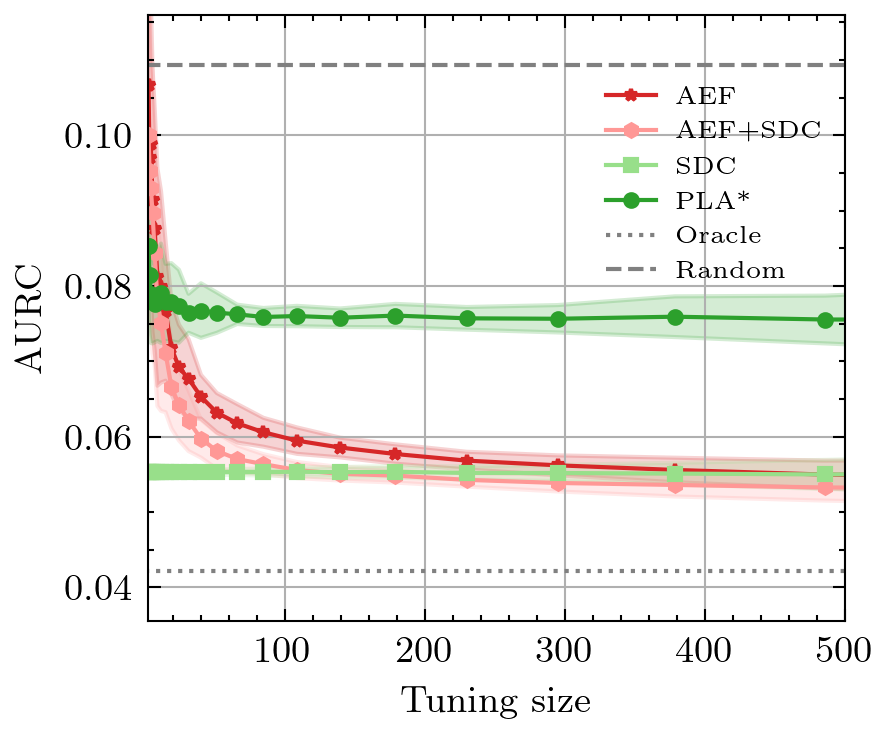

In [ ]:
min_prop = 2/len(y)
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)
max_tuning_size=int(len(y)/2)

df_naurcs_mean.rename(columns={'PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'PLA':'PLA*'},inplace=True)
df_naurcs_mean = df_naurcs_mean[['AEF', 'AEF+SDC', 'SDC','PLA*']]
df_std_dev = df_std_dev[['AEF', 'AEF+SDC', 'SDC','PLA*']]

# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_naurcs_mean.columns[:]):
    plt.plot(tuning_size_arrays*len(y), df_naurcs_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*len(y), df_naurcs_mean[column] - df_std_dev[column], df_naurcs_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.hlines(aurcs_all[task_data]['Ideal'], min_prop, max_tuning_size, **styles['oracle'])
plt.hlines(aurcs_all[task_data]['Random'], min_prop, max_tuning_size, **styles['random'])

plt.xlabel('Tuning size')
plt.ylabel('AURC')


y_min, y_max = adjust_axis_limits(aurcs_all[task_data]['Random'], aurcs_all[task_data]['Ideal'])
plt.ylim(y_min, y_max)

#plt.ylim(top=aurcs_all[task_data]['Random']*1.2, bottom=aurcs_all['isic']['Ideal']*0.8)

plt.xlim(left =2 ,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
plt.legend(loc='center right', ncol=1, frameon=False,
    bbox_to_anchor=(1, 0.72))

plt.savefig("./graphs/ISIC_Shuffle_Split_Test_all.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.076
PLA@10 stdev: 0.001
AEF@10 mean: 0.060
AEF@10 stdev: 0.002
AEF+SDC@10 mean: 0.056
AEF+SDC@10 stdev: 0.001 

PLA@50 mean: 0.076
PLA@50 stdev: 0.003
AEF@50 mean: 0.055
AEF@50 stdev: 0.002
AEF+SDC@50 mean: 0.053
AEF+SDC@50 stdev: 0.002 



# BraTS

In [ ]:
task = 'brats'
df_naurcs_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}.pkl')

data = np.load('./data/brats.npz')

y = data['y']

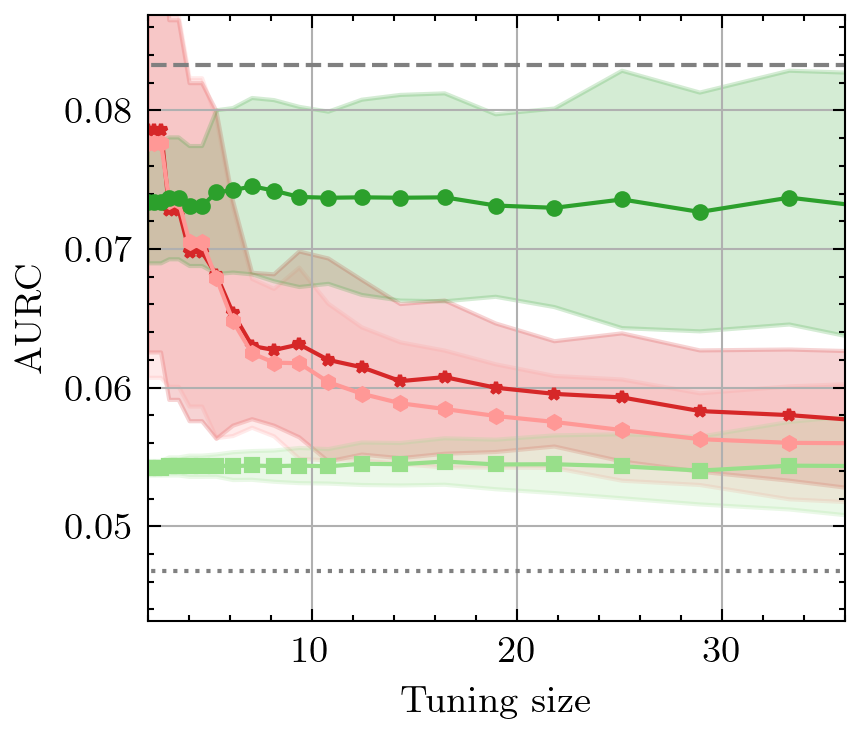

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import scienceplots
task_data = 'brats'
#min_prop = 2/len(y)
min_prop = 2/73
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)[:23]
#max_tuning_size=int(len(y)/2)
max_tuning_size=int(73/2)

df_naurcs_mean.rename(columns={'PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'PLA':'PLA*'},inplace=True)
df_naurcs_mean = df_naurcs_mean[['AEF', 'AEF+SDC', 'SDC','PLA*']]
df_std_dev = df_std_dev[['AEF', 'AEF+SDC', 'SDC','PLA*']]
# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_naurcs_mean.columns[:]):
    #plt.plot(tuning_size_arrays*len(y), df_naurcs_mean[column], label=column, **styles[column.lower().replace("+","_")])
    #plt.fill_between(tuning_size_arrays*len(y), df_naurcs_mean[column] - df_std_dev[column], df_naurcs_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])
    plt.plot(tuning_size_arrays*73, df_naurcs_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*73, df_naurcs_mean[column] - df_std_dev[column], df_naurcs_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.hlines(aurcs_all[task_data]['Ideal'], min_prop, max_tuning_size, **styles['oracle'])
plt.hlines(aurcs_all[task_data]['Random'], min_prop, max_tuning_size, **styles['random'])

plt.xlabel('Tuning size')
plt.ylabel('AURC')


y_min, y_max = adjust_axis_limits(aurcs_all[task_data]['Random'], aurcs_all[task_data]['Ideal'],visual_position_ideal=0.1)
plt.ylim(y_min, y_max)

#plt.ylim(top=aurcs_all[task_data]['Random']*1.2, bottom=aurcs_all['isic']['Ideal']*0.8)

plt.xlim(left =2 ,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
#plt.legend(loc="upper right", ncol=3)
plt.savefig("../Journal_Graphs/BraTS_Shuffle_Split_Test_all.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.074
PLA@10 stdev: 0.006
AEF@10 mean: 0.063
AEF@10 stdev: 0.005
AEF+SDC@10 mean: 0.062
AEF+SDC@10 stdev: 0.005 

PLA@50 mean: 0.073
PLA@50 stdev: 0.010
AEF@50 mean: 0.058
AEF@50 stdev: 0.005
AEF+SDC@50 mean: 0.056
AEF+SDC@50 stdev: 0.004 



# MSWML - ID

In [ ]:
task = 'mswml'
df_naurcs_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}.pkl')

with open('../mswml/eval_in_gt.pkl', 'rb') as file:
    # Save the list to the file
    y =  pickle.load(file)

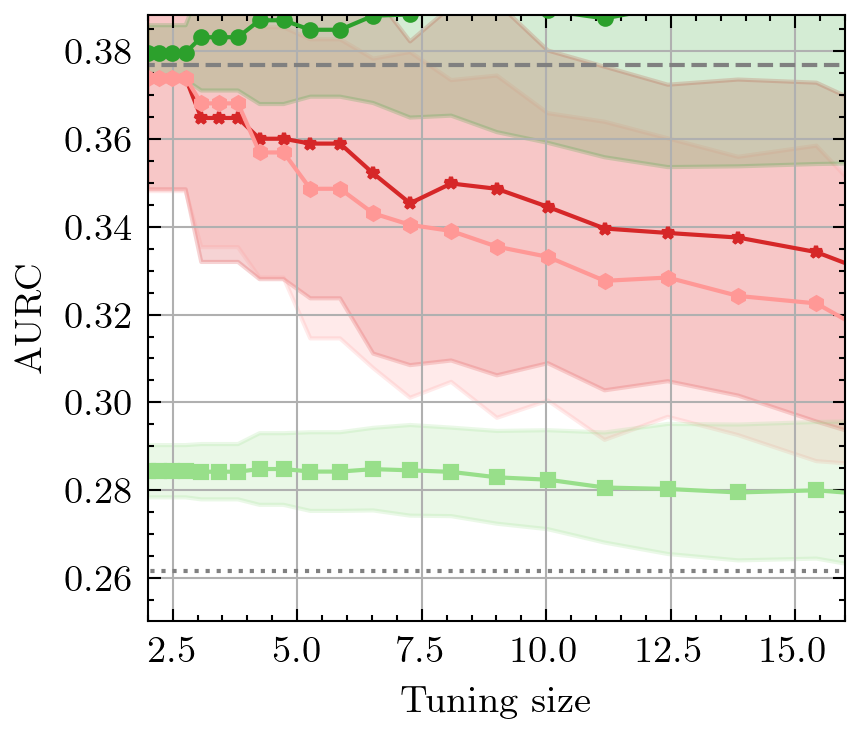

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import scienceplots
task_data = 'mswml'
min_prop = 2/len(y)
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)
max_tuning_size=int(len(y)/2)

df_naurcs_mean.rename(columns={'PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'PLA':'PLA*'},inplace=True)
df_naurcs_mean = df_naurcs_mean[['AEF', 'AEF+SDC', 'SDC','PLA*']]
df_std_dev = df_std_dev[['AEF', 'AEF+SDC', 'SDC','PLA*']]
# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_naurcs_mean.columns[:]):
    plt.plot(tuning_size_arrays*len(y), df_naurcs_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*len(y), df_naurcs_mean[column] - df_std_dev[column], df_naurcs_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.hlines(aurcs_all[task_data]['Ideal'], min_prop, max_tuning_size, **styles['oracle'])
plt.hlines(aurcs_all[task_data]['Random'], min_prop, max_tuning_size, **styles['random'])

plt.xlabel('Tuning size')
plt.ylabel('AURC')


y_min, y_max = adjust_axis_limits(aurcs_all[task_data]['Random'], aurcs_all[task_data]['Ideal'],visual_position_ideal=0.1)
plt.ylim(y_min, y_max)

#plt.ylim(top=aurcs_all[task_data]['Random']*1.2, bottom=aurcs_all['isic']['Ideal']*0.8)

plt.xlim(left =2 ,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
#plt.legend(loc="upper right", ncol=3)
plt.savefig("../Journal_Graphs/MSWML_Shuffle_Split_Test_all.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.383
PLA@10 stdev: 0.012
AEF@10 mean: 0.365
AEF@10 stdev: 0.033
AEF+SDC@10 mean: 0.368
AEF+SDC@10 stdev: 0.033 

PLA@50 mean: 0.395
PLA@50 stdev: 0.041
AEF@50 mean: 0.330
AEF@50 stdev: 0.038
AEF+SDC@50 mean: 0.316
AEF+SDC@50 stdev: 0.030 



# Polyp - ID

In [ ]:
task = 'polyp'
df_naurcs_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}.pkl')

data = np.load('./data/polyp-pvt.npz')

y = data['y']

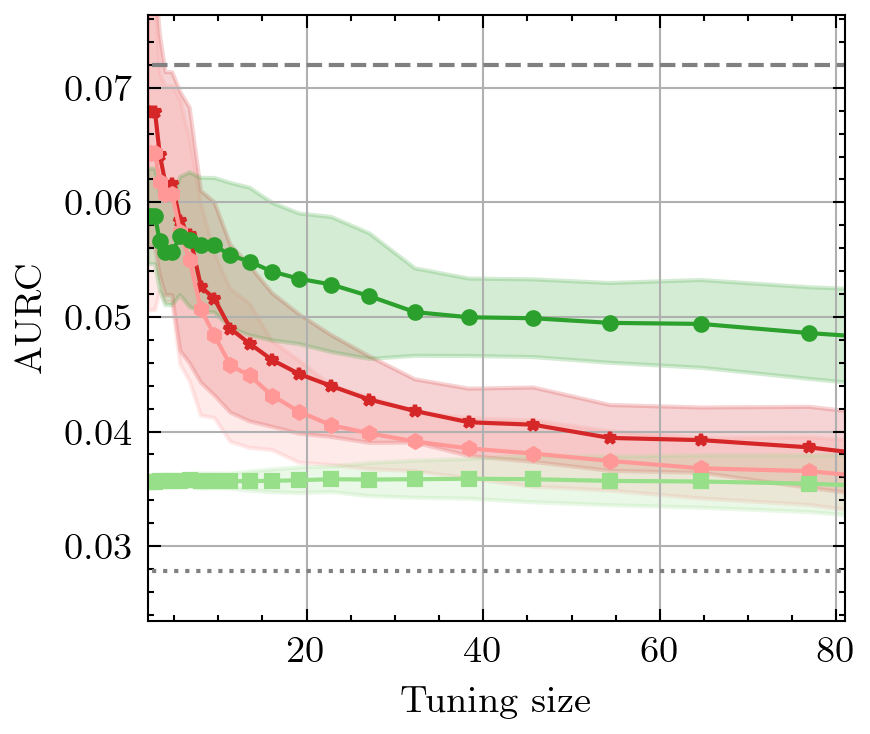

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import scienceplots
task_data = 'polyp-pvt'
min_prop = 2/len(y)
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)
max_tuning_size=int(len(y)/2)

df_naurcs_mean.rename(columns={'PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'PLA':'PLA*'},inplace=True)
df_naurcs_mean = df_naurcs_mean[['AEF', 'AEF+SDC', 'SDC','PLA*']]
df_std_dev = df_std_dev[['AEF', 'AEF+SDC', 'SDC','PLA*']]
# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_naurcs_mean.columns[:]):
    plt.plot(tuning_size_arrays*len(y), df_naurcs_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*len(y), df_naurcs_mean[column] - df_std_dev[column], df_naurcs_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.hlines(aurcs_all[task_data]['Ideal'], min_prop, max_tuning_size, **styles['oracle'])
plt.hlines(aurcs_all[task_data]['Random'], min_prop, max_tuning_size, **styles['random'])

plt.xlabel('Tuning size')
plt.ylabel('AURC')


y_min, y_max = adjust_axis_limits(aurcs_all[task_data]['Random'], aurcs_all[task_data]['Ideal'],visual_position_ideal=0.1)
plt.ylim(y_min, y_max)

#plt.ylim(top=aurcs_all[task_data]['Random']*1.2, bottom=aurcs_all['isic']['Ideal']*0.8)

plt.xlim(left =2 ,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
#plt.legend(loc="upper right", ncol=3)
plt.savefig("../Journal_Graphs/Polyp_PVT_Shuffle_Split_Test_all.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.054
PLA@10 stdev: 0.006
AEF@10 mean: 0.046
AEF@10 stdev: 0.006
AEF+SDC@10 mean: 0.043
AEF+SDC@10 stdev: 0.005 

PLA@50 mean: 0.048
PLA@50 stdev: 0.004
AEF@50 mean: 0.038
AEF@50 stdev: 0.004
AEF+SDC@50 mean: 0.036
AEF+SDC@50 stdev: 0.003 



# Optic Cup -ID

In [ ]:
task = 'optic_cup'
df_naurcs_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}.pkl')

data = np.load('./data/optic_cup.npz')

y = data['y']


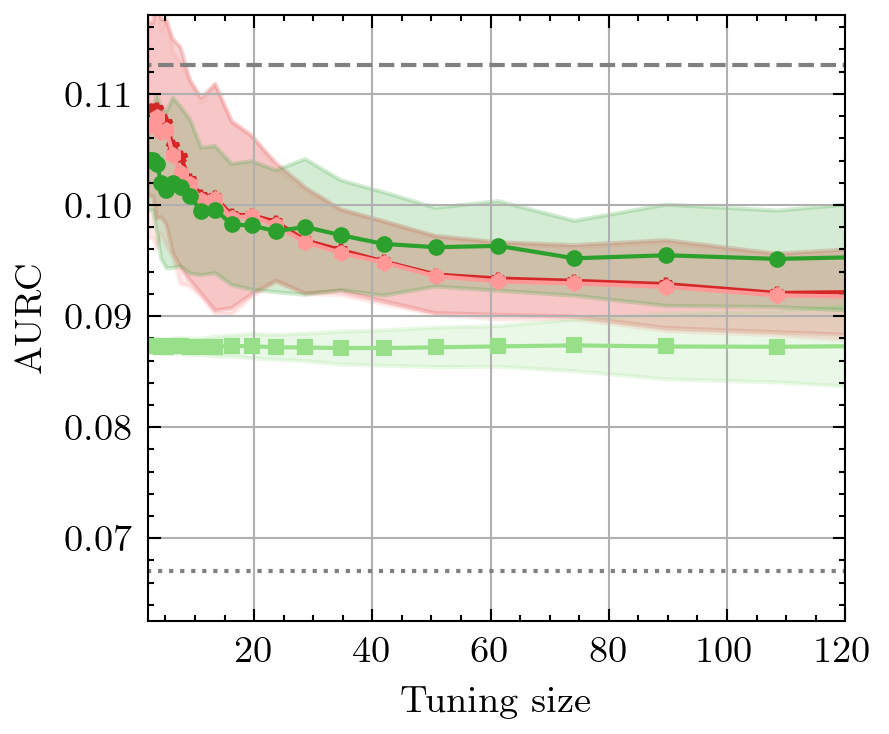

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import scienceplots
task_data = 'refuge'
min_prop = 2/len(y)
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)
max_tuning_size=int(len(y)/2)

df_naurcs_mean.rename(columns={'PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'PLA':'PLA*'},inplace=True)
df_naurcs_mean = df_naurcs_mean[['AEF', 'AEF+SDC', 'SDC','PLA*']]
df_std_dev = df_std_dev[['AEF', 'AEF+SDC', 'SDC','PLA*']]
# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_naurcs_mean.columns[:]):
    plt.plot(tuning_size_arrays*len(y), df_naurcs_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*len(y), df_naurcs_mean[column] - df_std_dev[column], df_naurcs_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.hlines(aurcs_all[task_data]['Ideal'], min_prop, max_tuning_size, **styles['oracle'])
plt.hlines(aurcs_all[task_data]['Random'], min_prop, max_tuning_size, **styles['random'])

plt.xlabel('Tuning size')
plt.ylabel('AURC')


y_min, y_max = adjust_axis_limits(aurcs_all[task_data]['Random'], aurcs_all[task_data]['Ideal'],visual_position_ideal=0.1)
plt.ylim(y_min, y_max)

#plt.ylim(top=aurcs_all[task_data]['Random']*1.2, bottom=aurcs_all['isic']['Ideal']*0.8)

plt.xlim(left =2 ,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
#plt.legend(loc="upper right", ncol=3)
plt.savefig("../Journal_Graphs/REFUGE_Shuffle_Split_Test_all.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.098
PLA@10 stdev: 0.006
AEF@10 mean: 0.098
AEF@10 stdev: 0.005
AEF+SDC@10 mean: 0.098
AEF+SDC@10 stdev: 0.005 

PLA@50 mean: 0.095
PLA@50 stdev: 0.005
AEF@50 mean: 0.092
AEF@50 stdev: 0.004
AEF+SDC@50 mean: 0.092
AEF+SDC@50 stdev: 0.004 



# BUSI

In [ ]:
task = 'busi'
df_naurcs_mean = pd.read_pickle(f'df_aurcs_mean_final_{task}.pkl')
df_std_dev = pd.read_pickle(f'df_aurcs_std_final_{task}.pkl')

data = np.load('./data/busi.npz')

y = data['y']

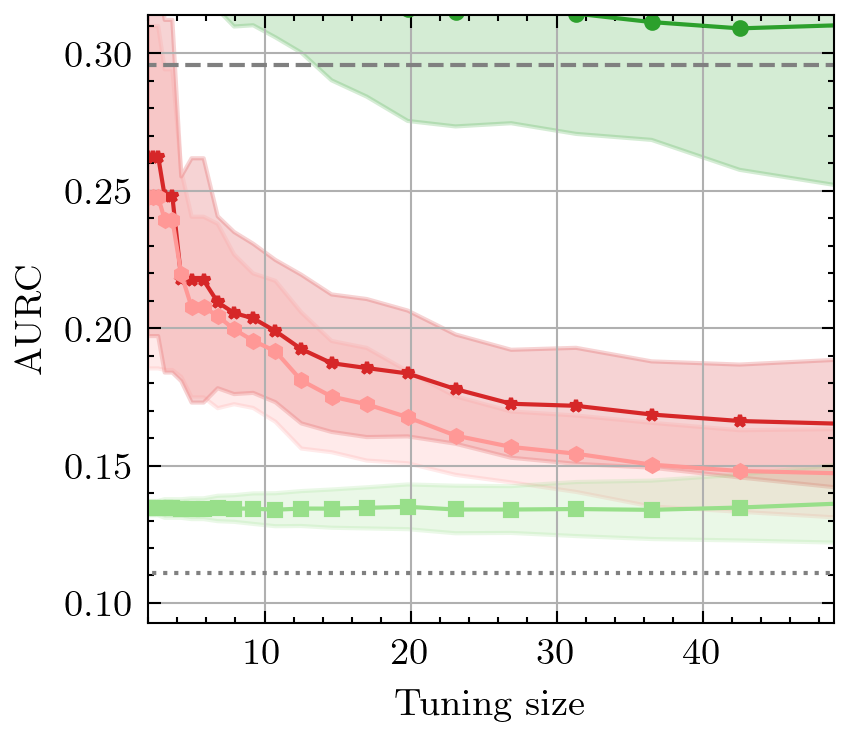

In [ ]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import scienceplots
task_data = 'busi'
min_prop = 2/len(y)
tuning_size_arrays = np.logspace(np.log10(min_prop), np.log10(0.8), num=25)
max_tuning_size=int(len(y)/2)

df_naurcs_mean.rename(columns={'PLA':'PLA*'},inplace=True)
df_std_dev.rename(columns={'PLA':'PLA*'},inplace=True)
df_naurcs_mean = df_naurcs_mean[['AEF', 'AEF+SDC', 'SDC','PLA*']]
df_std_dev = df_std_dev[['AEF', 'AEF+SDC', 'SDC','PLA*']]

# Plotting
#plt.figure(figsize=(4.5, 3.25))

for i, column in enumerate(df_naurcs_mean.columns[:]):
    plt.plot(tuning_size_arrays*len(y), df_naurcs_mean[column], label=column, **styles[column.lower().replace("+","_")])
    plt.fill_between(tuning_size_arrays*len(y), df_naurcs_mean[column] - df_std_dev[column], df_naurcs_mean[column] + df_std_dev[column], alpha=0.2, color = styles[column.lower().replace("+","_")]['color'])

plt.hlines(aurcs_all[task_data]['Ideal'], min_prop, max_tuning_size, **styles['oracle'])
plt.hlines(aurcs_all[task_data]['Random'], min_prop, max_tuning_size, **styles['random'])

plt.xlabel('Tuning size')
plt.ylabel('AURC')


y_min, y_max = adjust_axis_limits(aurcs_all[task_data]['Random'], aurcs_all[task_data]['Ideal'],visual_position_ideal=0.1)
plt.ylim(y_min, y_max)

#plt.ylim(top=aurcs_all[task_data]['Random']*1.2, bottom=aurcs_all['isic']['Ideal']*0.8)

plt.xlim(left =2 ,right=max_tuning_size)
#ticks = np.arange(0, 850, 50)   # Generating ticks from 0 to 10 with an interval of 1
#plt.xticks(ticks)  
#plt.title('Tuning size x NAURC - ISIC')
#plt.legend(loc="upper right", ncol=3)
plt.tight_layout()
plt.savefig("../Journal_Graphs/BUSI_Shuffle_Split_Test_all.pdf", format="pdf")
plt.show()

In [ ]:
tuning = 0.1
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@10 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@10 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@10 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))

tuning = 0.5
index_0, index_1 = find_closest_indices(tuning_size_arrays, tuning)
print('PLA@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['PLA*']))
print('PLA@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['PLA*'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['PLA*']))
print('AEF@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF']))
print('AEF@50 stdev: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF']))
print('AEF+SDC@50 mean: %.3f' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_naurcs_mean.iloc[df_naurcs_mean.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_naurcs_mean.iloc[df_naurcs_mean.index[index_1]]['AEF+SDC']))
print('AEF+SDC@50 stdev: %.3f \n' %linear_interpolation(tuning, tuning_size_arrays[index_0], df_std_dev.iloc[df_std_dev.index[index_0]]['AEF+SDC'],tuning_size_arrays[index_1], df_std_dev.iloc[df_std_dev.index[index_1]]['AEF+SDC']))


PLA@10 mean: 0.331
PLA@10 stdev: 0.022
AEF@10 mean: 0.202
AEF@10 stdev: 0.027
AEF+SDC@10 mean: 0.194
AEF+SDC@10 stdev: 0.025 

PLA@50 mean: 0.310
PLA@50 stdev: 0.058
AEF@50 mean: 0.165
AEF@50 stdev: 0.023
AEF+SDC@50 mean: 0.147
AEF+SDC@50 stdev: 0.016 

